In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
sessions = pd.read_excel(r"C:\Users\nazma\Downloads\EV_Charging_Analytics_Dataset.xlsx",
    sheet_name="Charging_Sessions")

stations = pd.read_excel(r"C:\Users\nazma\Downloads\EV_Charging_Analytics_Dataset.xlsx",
    sheet_name="Stations")

customers = pd.read_excel(r"C:\Users\nazma\Downloads\EV_Charging_Analytics_Dataset.xlsx",
    sheet_name="Customers")

In [6]:
sessions.head()

,Session_ID,Date,Start_Time,End_Time,Station_ID,Customer_ID,EV_Model,Charger_Type,Energy_Consumed_kWh,Charging_Duration_Min,Revenue,Payment_Method,Session_Status
0,CH000001,2024-11-15,18:37:49,20:25:49,S010,C00695,Mercedes EQB,AC,23.74,108,306.62,Debit Card,Completed
1,CH000002,2025-11-21,06:59:38,08:04:38,S026,C00341,BMW i4,DC Fast,32.24,65,607.08,Debit Card,Completed
2,CH000003,2024-11-15,19:00:55,19:10:55,S018,C02079,Mahindra XUV400 EV,DC Fast,0.94,10,0.00,Cash,Failed
3,CH000004,2025-09-27,16:48:04,18:02:04,S004,C00544,BYD Atto 3,DC Fast,28.78,74,551.61,UPI,Completed
4,CH000005,2025-02-24,04:46:28,05:44:28,S012,C02311,Mahindra XUV400 EV,DC Fast,24.36,58,490.12,Cash,Completed


In [7]:
stations.head()

,Station_ID,Station_Name,City,State,Location_Type,Charger_Count,Station_Status
0,S001,EV Charge Hub 01,Hyderabad,Telangana,Office Area,5,Maintenance
1,S002,EV Charge Hub 02,Mumbai,Maharashtra,Mall,17,Active
2,S003,EV Charge Hub 03,Ahmedabad,Gujarat,Parking Lot,12,Active
3,S004,EV Charge Hub 04,Delhi,Delhi,Mall,6,Active
4,S005,EV Charge Hub 05,Delhi,Delhi,Parking Lot,9,Active


In [8]:
customers.head()

,Customer_ID,Customer_Type,Gender,Age_Group,Membership,Registration_Date
0,C00001,Individual,Male,56+,Member,2024-11-11
1,C00002,Corporate,Male,18-25,Non-Member,2022-01-18
2,C00003,Fleet,Female,18-25,Non-Member,2022-03-01
3,C00004,Corporate,Female,46-55,Member,2025-02-24
4,C00005,Corporate,Female,36-45,Member,2025-08-01


In [9]:
print("Sessions Shape:", sessions.shape)
print("Stations Shape:", stations.shape)
print("Customers Shape:", customers.shape)

Sessions Shape: (15000, 13)
Stations Shape: (30, 7)
Customers Shape: (2500, 6)


##checking column names

In [10]:
print(sessions.columns)

Index(['Session_ID', 'Date', 'Start_Time', 'End_Time', 'Station_ID',
       'Customer_ID', 'EV_Model', 'Charger_Type', 'Energy_Consumed_kWh',
       'Charging_Duration_Min', 'Revenue', 'Payment_Method', 'Session_Status'],
      dtype='str')


In [11]:
print(stations.columns)

Index(['Station_ID', 'Station_Name', 'City', 'State', 'Location_Type',
       'Charger_Count', 'Station_Status'],
      dtype='str')


In [12]:
print(customers.columns)

Index(['Customer_ID', 'Customer_Type', 'Gender', 'Age_Group', 'Membership',
       'Registration_Date'],
      dtype='str')


#Check Data Types and Missing Values

In [13]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Session_ID             15000 non-null  str           
 1   Date                   15000 non-null  datetime64[us]
 2   Start_Time             15000 non-null  str           
 3   End_Time               15000 non-null  str           
 4   Station_ID             15000 non-null  str           
 5   Customer_ID            15000 non-null  str           
 6   EV_Model               15000 non-null  str           
 7   Charger_Type           15000 non-null  str           
 8   Energy_Consumed_kWh    14995 non-null  float64       
 9   Charging_Duration_Min  15000 non-null  int64         
 10  Revenue                15000 non-null  float64       
 11  Payment_Method         15000 non-null  str           
 12  Session_Status         15000 non-null  str           
dtypes: datetime6

In [14]:
stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Station_ID      30 non-null     str  
 1   Station_Name    30 non-null     str  
 2   City            30 non-null     str  
 3   State           30 non-null     str  
 4   Location_Type   30 non-null     str  
 5   Charger_Count   30 non-null     int64
 6   Station_Status  30 non-null     str  
dtypes: int64(1), str(6)
memory usage: 3.3 KB


In [15]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer_ID        2500 non-null   str           
 1   Customer_Type      2500 non-null   str           
 2   Gender             2500 non-null   str           
 3   Age_Group          2500 non-null   str           
 4   Membership         2500 non-null   str           
 5   Registration_Date  2500 non-null   datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 194.4 KB


#Statistical Summary

In [16]:
sessions.describe()

,Date,Energy_Consumed_kWh,Charging_Duration_Min,Revenue
count,15000,14995.000000,15000.000000,15000.000000
mean,2024-12-31 06:13:55.200000,19.651128,62.674933,300.910978
min,2024-01-01 00:00:00,0.000000,1.000000,0.000000
25%,2024-07-03 00:00:00,7.445000,22.000000,105.807500
50%,2025-01-02 00:00:00,19.620000,55.000000,296.345000
75%,2025-06-29 00:00:00,31.360000,87.000000,473.300000
max,2025-12-31 00:00:00,52.680000,180.000000,1015.200000
std,NaN,13.763046,47.811897,224.761728


In [17]:
sessions.describe(include="all")

,Session_ID,Date,Start_Time,End_Time,Station_ID,Customer_ID,EV_Model,Charger_Type,Energy_Consumed_kWh,Charging_Duration_Min,Revenue,Payment_Method,Session_Status
count,15000,15000,15000,15000,15000,15000,15000,15000,14995.000000,15000.000000,15000.000000,15000,15000
unique,15000,NaN,13403,13417,30,2497,11,2,NaN,NaN,NaN,6,2
top,CH000001,NaN,20:49:30,20:22:14,S004,C00600,Kia EV6,AC,NaN,NaN,NaN,Debit Card,Completed
freq,1,NaN,4,4,533,17,1547,7514,NaN,NaN,NaN,3064,11980
mean,NaN,2024-12-31 06:13:55.200000,NaN,NaN,NaN,NaN,NaN,NaN,19.651128,62.674933,300.910978,NaN,NaN
min,NaN,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN
25%,NaN,2024-07-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,7.445000,22.000000,105.807500,NaN,NaN
50%,NaN,2025-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,19.620000,55.000000,296.345000,NaN,NaN
75%,NaN,2025-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,31.360000,87.000000,473.300000,NaN,NaN
max,NaN,2025-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,52.680000,180.000000,1015.200000,NaN,NaN


In [18]:
#Check Missing Values

In [19]:
sessions.isnull().sum()

Session_ID               0
Date                     0
Start_Time               0
End_Time                 0
Station_ID               0
Customer_ID              0
EV_Model                 0
Charger_Type             0
Energy_Consumed_kWh      5
Charging_Duration_Min    0
Revenue                  0
Payment_Method           0
Session_Status           0
dtype: int64

In [20]:
#Check Duplicate Records

In [21]:
sessions.duplicated().sum()

np.int64(0)

In [22]:
#Check Invalid Negative Energy Values

In [23]:
sessions[sessions["Energy_Consumed_kWh"] < 0]

,Session_ID,Date,Start_Time,End_Time,Station_ID,Customer_ID,EV_Model,Charger_Type,Energy_Consumed_kWh,Charging_Duration_Min,Revenue,Payment_Method,Session_Status


In [24]:
(sessions["Energy_Consumed_kWh"] < 0).sum()

np.int64(0)

In [25]:
#Handle Missing Values

In [26]:
sessions["EV_Model"] = sessions["EV_Model"].fillna("Unknown")

sessions["Energy_Consumed_kWh"] = sessions["Energy_Consumed_kWh"].fillna("Unknown")

In [27]:
sessions.isnull().sum()

Session_ID               0
Date                     0
Start_Time               0
End_Time                 0
Station_ID               0
Customer_ID              0
EV_Model                 0
Charger_Type             0
Energy_Consumed_kWh      0
Charging_Duration_Min    0
Revenue                  0
Payment_Method           0
Session_Status           0
dtype: int64

In [28]:
sessions.shape

(15000, 13)

In [29]:
##Python EDA & Visualization

In [30]:
sessions["Date"] = pd.to_datetime(sessions["Date"])
sessions["Year"] = sessions["Date"].dt.year
sessions["Month"] = sessions["Date"].dt.month_name()
sessions["Month_Number"] = sessions["Date"].dt.month
sessions["Charging_Hour"] = pd.to_datetime(
    sessions["Start_Time"],
    format="%H:%M:%S"
).dt.hour

In [31]:
#Monthly Revenue Trend

In [32]:
monthly_revenue = sessions[
    sessions["Session_Status"] == "Completed"
].groupby(
    ["Year", "Month_Number", "Month"]
)["Revenue"].sum().reset_index()

In [33]:
monthly_revenue = monthly_revenue.sort_values(
    ["Year", "Month_Number"]
)

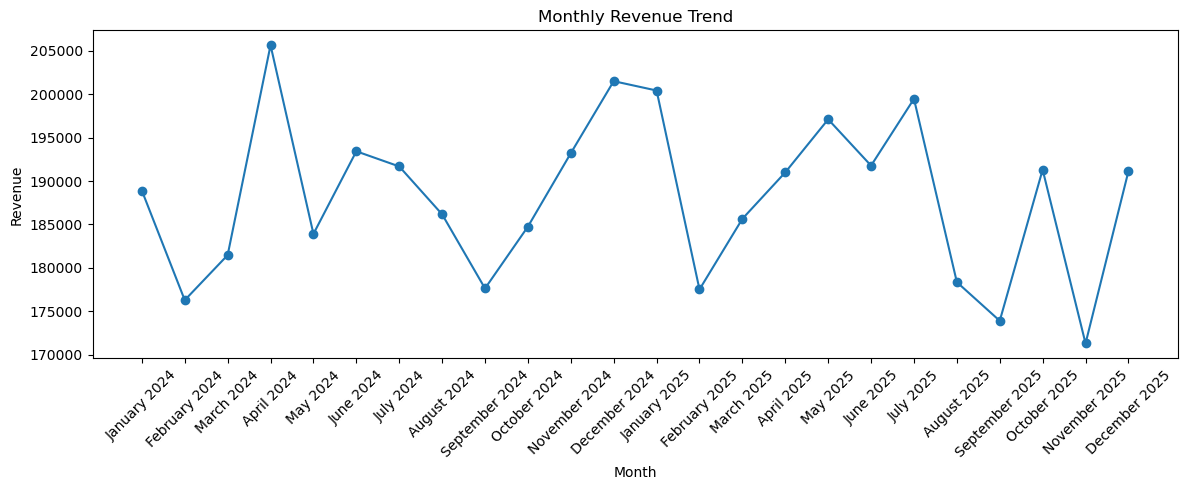

In [34]:
plt.figure(figsize=(12,5))
plt.plot( monthly_revenue["Month"] + " " + monthly_revenue["Year"].astype(str),
    monthly_revenue["Revenue"],
    marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
#Revenue by City

In [36]:
city_data = sessions.merge(
    stations[["Station_ID", "City"]],
    on="Station_ID",
    how="left"
)
city_revenue = city_data[
    city_data["Session_Status"] == "Completed"
].groupby("City")["Revenue"].sum().sort_values(ascending=False)

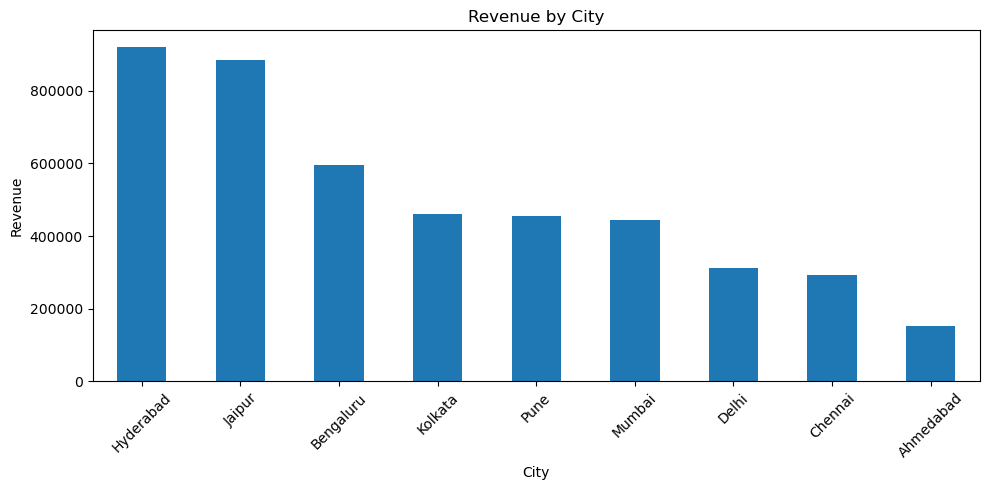

In [37]:
plt.figure(figsize=(10,5))

city_revenue.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
#Most Popular EV Models

In [39]:
ev_usage = sessions[
    sessions["Session_Status"] == "Completed"
]["EV_Model"].value_counts()

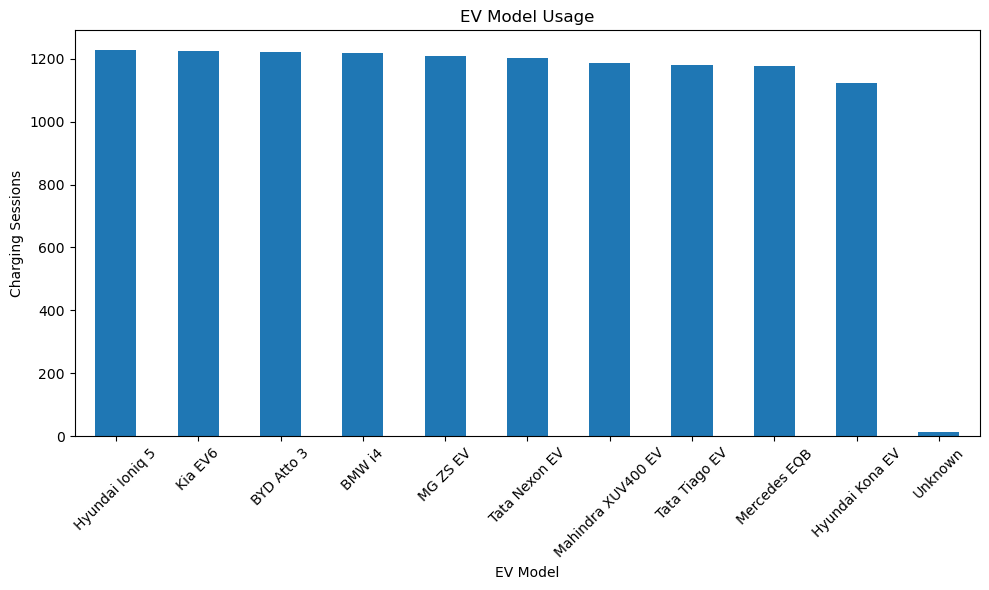

In [40]:
plt.figure(figsize=(10,6))

ev_usage.plot(kind="bar")

plt.title("EV Model Usage")
plt.xlabel("EV Model")
plt.ylabel("Charging Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
#Completed vs Failed Sessions

In [42]:
status_count = sessions["Session_Status"].value_counts()

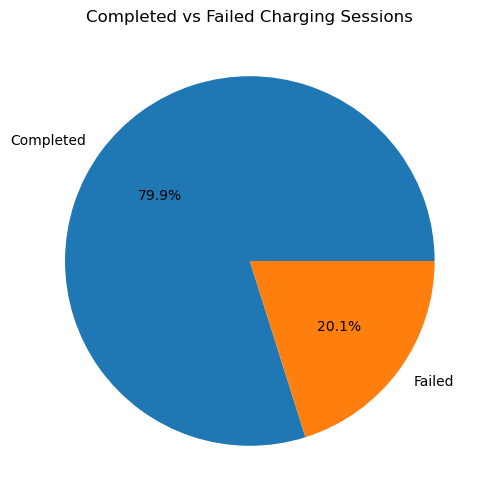

In [43]:
plt.figure(figsize=(6,6))

status_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Completed vs Failed Charging Sessions")
plt.ylabel("")
plt.show()

In [44]:
#Outlier Analysis for revenue

In [50]:
print("EV Charging Analytics - Key Insights")
print("--------------------------------------")
print("1. Identified the highest revenue-generating cities and stations.")
print("2. Identified peak charging hours to understand demand patterns.")
print("3. Compared AC and DC Fast charger usage.")
print("4. Identified the most frequently used EV models.")
print("5. Analysed completed and failed charging sessions.")
print("6. Identified stations with relatively high failure rates.")
print("7. Analysed the relationship between energy consumption and revenue.")

EV Charging Analytics - Key Insights
--------------------------------------
1. Identified the highest revenue-generating cities and stations.
2. Identified peak charging hours to understand demand patterns.
3. Compared AC and DC Fast charger usage.
4. Identified the most frequently used EV models.
5. Analysed completed and failed charging sessions.
6. Identified stations with relatively high failure rates.
7. Analysed the relationship between energy consumption and revenue.
